# CropGuard AI — Custom CNN Baseline Training

This notebook trains the baseline Custom CNN model for CropGuard AI using Kaggle GPU.

Dataset:
- Kaggle: vipoooool/new-plant-diseases-dataset
- 38 plant disease / healthy classes
- Train and validation folders already available

Purpose:
- Train Custom CNN baseline
- Use data augmentation
- Handle class imbalance using class weights
- Save trained model
- Save training curves
- Save classification report
- Save confusion matrix
- Export outputs for PyCharm project

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-23 14:15:48.576878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782224148.988573      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782224149.103157      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782224150.112407      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782224150.112466      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782224150.112471      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
from pathlib import Path

def find_dataset_root():
    # Best path when dataset is added using Kaggle "Add Input"
    input_root = Path("/kaggle/input")

    for train_dir in input_root.rglob("train"):
        valid_dir = train_dir.parent / "valid"

        if valid_dir.exists():
            return train_dir.parent, train_dir, valid_dir

    raise FileNotFoundError(
        "Could not find train/valid folders. "
        "Make sure you added the dataset using Kaggle Add Input."
    )


DATASET_ROOT, TRAIN_DIR, VALID_DIR = find_dataset_root()

print("Dataset root:", DATASET_ROOT)
print("Train dir:", TRAIN_DIR)
print("Valid dir:", VALID_DIR)

Dataset root: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Train dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [4]:
from pathlib import Path
import json
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

WORKING_DIR = Path("/kaggle/working")

MODELS_DIR = WORKING_DIR / "models"
OUTPUTS_DIR = WORKING_DIR / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
LOGS_DIR = OUTPUTS_DIR / "training_logs"
ERROR_DIR = OUTPUTS_DIR / "error_analysis"

for folder in [MODELS_DIR, OUTPUTS_DIR, METRICS_DIR, LOGS_DIR, ERROR_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORKING_DIR)

Working directory: /kaggle/working


In [6]:
# Mixed precision can speed up training on Kaggle GPU.
# Final softmax layer will use float32 for stable probabilities.

from tensorflow.keras import mixed_precision

try:
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled:", e)

Mixed precision enabled: <DTypePolicy "mixed_float16">


In [7]:
def find_dataset_root():
    possible_roots = [
        Path("/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"),
        Path("/kaggle/input/new-plant-diseases-dataset"),
    ]

    for root in possible_roots:
        train_dir = root / "train"
        valid_dir = root / "valid"

        if train_dir.exists() and valid_dir.exists():
            return root, train_dir, valid_dir

    for train_dir in Path("/kaggle/input").rglob("train"):
        valid_dir = train_dir.parent / "valid"
        if valid_dir.exists():
            return train_dir.parent, train_dir, valid_dir

    raise FileNotFoundError("Could not find train/valid folders inside /kaggle/input.")


DATASET_ROOT, TRAIN_DIR, VALID_DIR = find_dataset_root()

print("Dataset root:", DATASET_ROOT)
print("Train dir:", TRAIN_DIR)
print("Valid dir:", VALID_DIR)

Dataset root: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Train dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [8]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
num_classes = len(class_names)

print("Number of classes:", num_classes)

train_counts = {}
valid_counts = {}

for class_name in class_names:
    train_class_dir = TRAIN_DIR / class_name
    valid_class_dir = VALID_DIR / class_name

    train_counts[class_name] = len([
        p for p in train_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    valid_counts[class_name] = len([
        p for p in valid_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

train_total = sum(train_counts.values())
valid_total = sum(valid_counts.values())

print("Total train images:", train_total)
print("Total valid images:", valid_total)

distribution_df = pd.DataFrame([
    {
        "class_name": class_name,
        "train_count": train_counts[class_name],
        "valid_count": valid_counts[class_name],
    }
    for class_name in class_names
])

distribution_df.to_csv(METRICS_DIR / "dataset_distribution_custom_cnn.csv", index=False)

distribution_df.head()

Number of classes: 38
Total train images: 70295
Total valid images: 17572


,class_name,train_count,valid_count
0,Apple___Apple_scab,2016,504
1,Apple___Black_rot,1987,497
2,Apple___Cedar_apple_rust,1760,440
3,Apple___healthy,2008,502
4,Blueberry___healthy,1816,454


In [9]:
class_indices = {str(index): class_name for index, class_name in enumerate(class_names)}

with open(MODELS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_indices, f, indent=4)

class_weights = {}

for index, class_name in enumerate(class_names):
    class_count = train_counts[class_name]
    class_weights[index] = train_total / (num_classes * class_count)

with open(MODELS_DIR / "class_weights.json", "w", encoding="utf-8") as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=4)

print("Saved class_indices.json")
print("Saved class_weights.json")

print("Sample class weights:")
list(class_weights.items())[:5]

Saved class_indices.json
Saved class_weights.json
Sample class weights:


[(0, 0.917593462823726),
 (1, 0.9309856170370566),
 (2, 1.0510616028708133),
 (3, 0.9212492136716293),
 (4, 1.0186500115928587)]

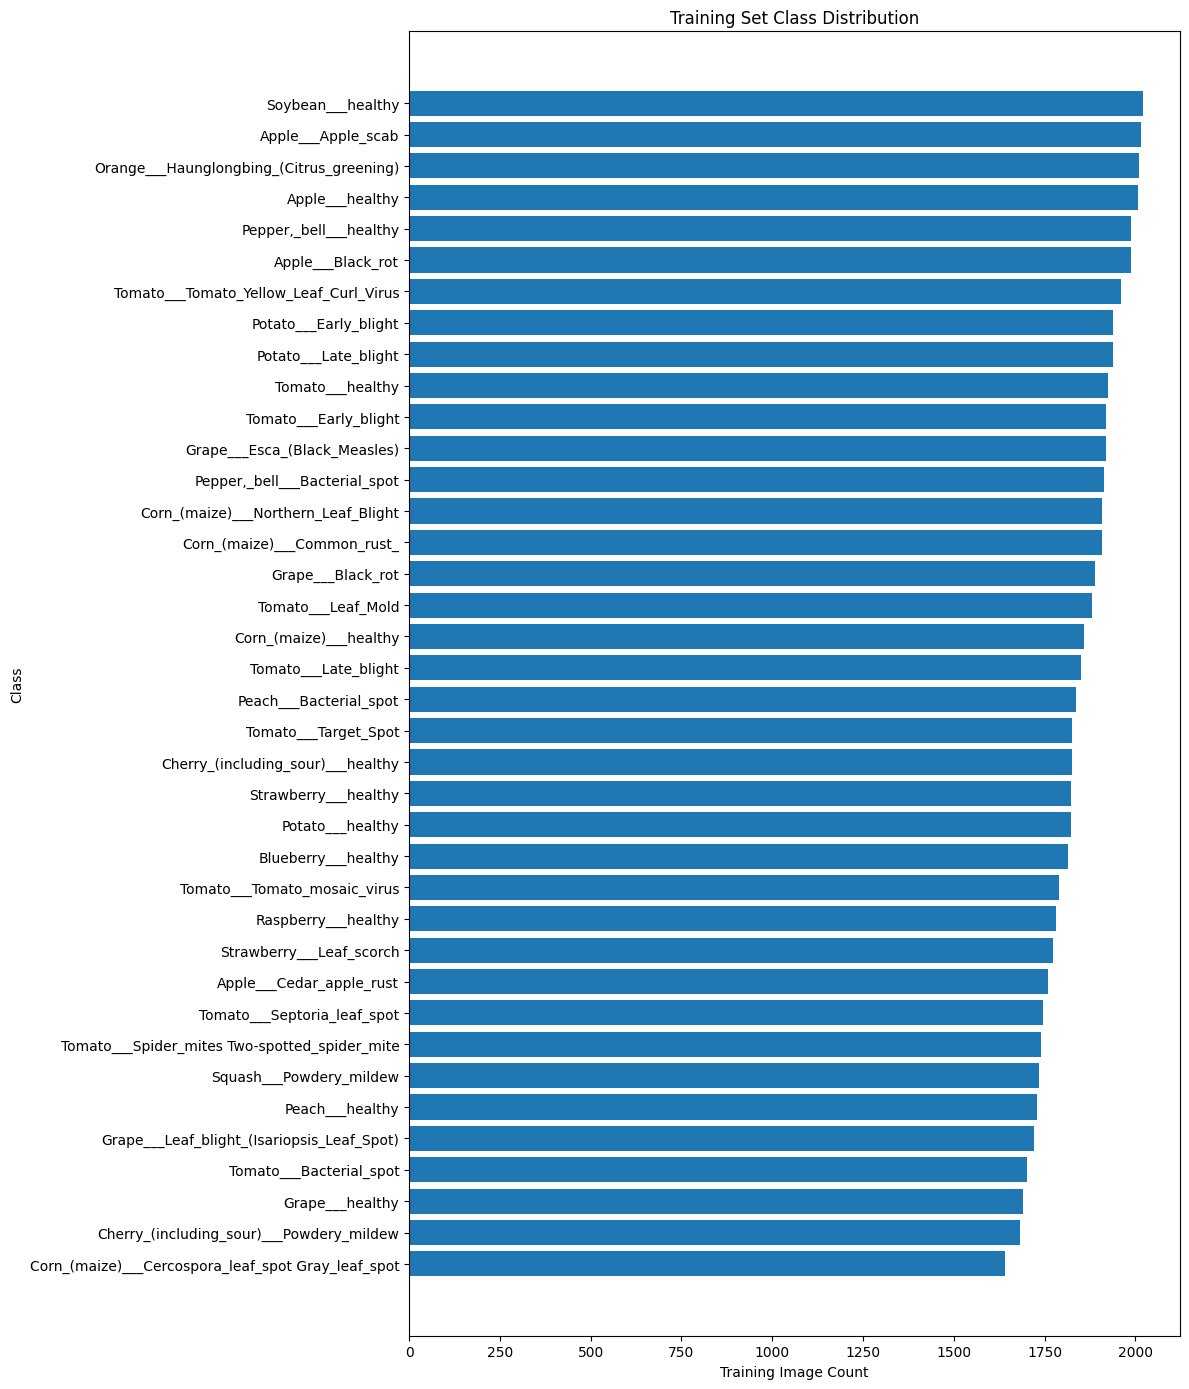

Saved: /kaggle/working/outputs/metrics/custom_cnn_class_distribution.png


In [10]:
plt.figure(figsize=(12, 14))
plot_df = distribution_df.sort_values("train_count", ascending=True)

plt.barh(plot_df["class_name"], plot_df["train_count"])
plt.xlabel("Training Image Count")
plt.ylabel("Class")
plt.title("Training Set Class Distribution")
plt.tight_layout()

class_distribution_path = METRICS_DIR / "custom_cnn_class_distribution.png"
plt.savefig(class_distribution_path, dpi=200)
plt.show()

print("Saved:", class_distribution_path)

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_names=train_ds.class_names,
)

print("Classes from TensorFlow loader:", len(train_ds.class_names))
print(train_ds.class_names[:5])

Found 70295 files belonging to 38 classes.


I0000 00:00:1782225889.859641      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782225889.865829      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Classes from TensorFlow loader: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [12]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Min pixel: 0.0
Max pixel: 255.0


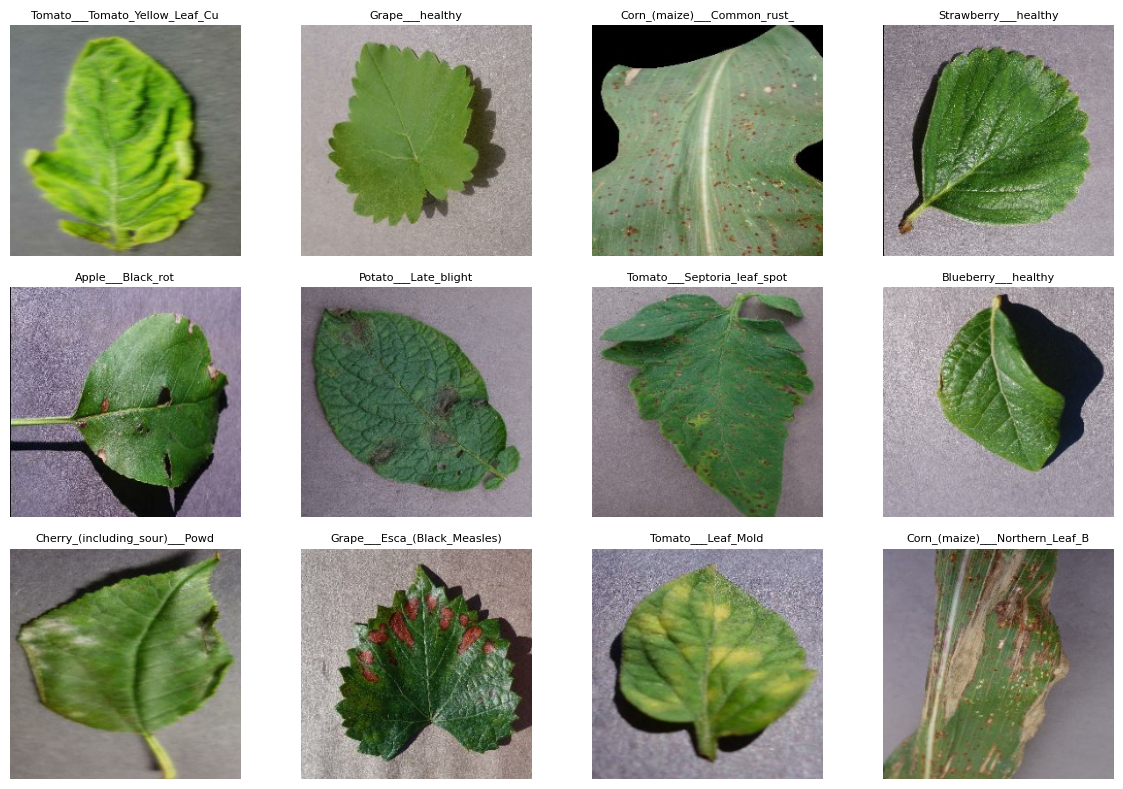

Saved: /kaggle/working/outputs/metrics/custom_cnn_sample_images.png


In [13]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])][:30], fontsize=8)
        plt.axis("off")

plt.tight_layout()

sample_path = METRICS_DIR / "custom_cnn_sample_images.png"
plt.savefig(sample_path, dpi=200)
plt.show()

print("Saved:", sample_path)

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

print("Datasets optimized with prefetch.")

Datasets optimized with prefetch.


In [15]:
def build_custom_cnn(num_classes):
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(384, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.40)(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    model = tf.keras.Model(inputs, outputs, name="custom_cnn_baseline")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
        ],
    )

    return model


model = build_custom_cnn(num_classes)
model.summary()

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 38)             │        14,630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,622 (4.93 MB)

 Trainable params: 1,289,894 (4.92 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [16]:
model_path = MODELS_DIR / "custom_cnn_baseline.keras"
history_csv_path = LOGS_DIR / "custom_cnn_history.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=history_csv_path,
        append=False,
    ),
]

print("Model will be saved to:", model_path)
print("History CSV will be saved to:", history_csv_path)

Model will be saved to: /kaggle/working/models/custom_cnn_baseline.keras
History CSV will be saved to: /kaggle/working/outputs/training_logs/custom_cnn_history.csv


In [17]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/10


I0000 00:00:1782225991.642951     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6470 - loss: 1.2233 - top_3_accuracy: 0.8357
Epoch 1: val_accuracy improved from None to 0.60705, saving model to /kaggle/working/models/custom_cnn_baseline.keras

Epoch 1: finished saving model to /kaggle/working/models/custom_cnn_baseline.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 307s 132ms/step - accuracy: 0.7901 - loss: 0.7099 - top_3_accuracy: 0.9280 - val_accuracy: 0.6070 - val_loss: 1.7515 - val_top_3_accuracy: 0.8178 - learning_rate: 0.0010
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9250 - loss: 0.2422 - top_3_accuracy: 0.9907
Epoch 2: val_accuracy improved from 0.60705 to 0.60801, saving model to /kaggle/working/models/custom_cnn_baseline.keras

Epoch 2: finished saving model to /kaggle/working/models/custom_cnn_baseline.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 262s 119ms/step - accuracy: 0.9358 - loss: 0.2068 - top_3_accuracy: 0.9924 - val_accuracy: 0.6080 - val_loss: 2.1001 - val_top_3_accuracy: 0.8

In [18]:
best_model = tf.keras.models.load_model(model_path)

results = best_model.evaluate(valid_ds, return_dict=True)

print("Final validation results:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9614 - loss: 0.1153 - top_3_accuracy: 0.9976
Final validation results:
accuracy: 0.9614
loss: 0.1153
top_3_accuracy: 0.9976


In [19]:
results_df = pd.DataFrame([
    {
        "model": "custom_cnn_baseline",
        "accuracy": results["accuracy"],
        "loss": results["loss"],
        "top_3_accuracy": results["top_3_accuracy"],
        "epochs": EPOCHS,
        "image_size": str(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "train_images": train_total,
        "valid_images": valid_total,
        "num_classes": num_classes,
    }
])

results_path = METRICS_DIR / "custom_cnn_results.csv"
results_df.to_csv(results_path, index=False)

results_df

,model,accuracy,loss,top_3_accuracy,epochs,image_size,batch_size,train_images,valid_images,num_classes
0,custom_cnn_baseline,0.961416,0.115325,0.99761,10,"(224, 224)",32,70295,17572,38


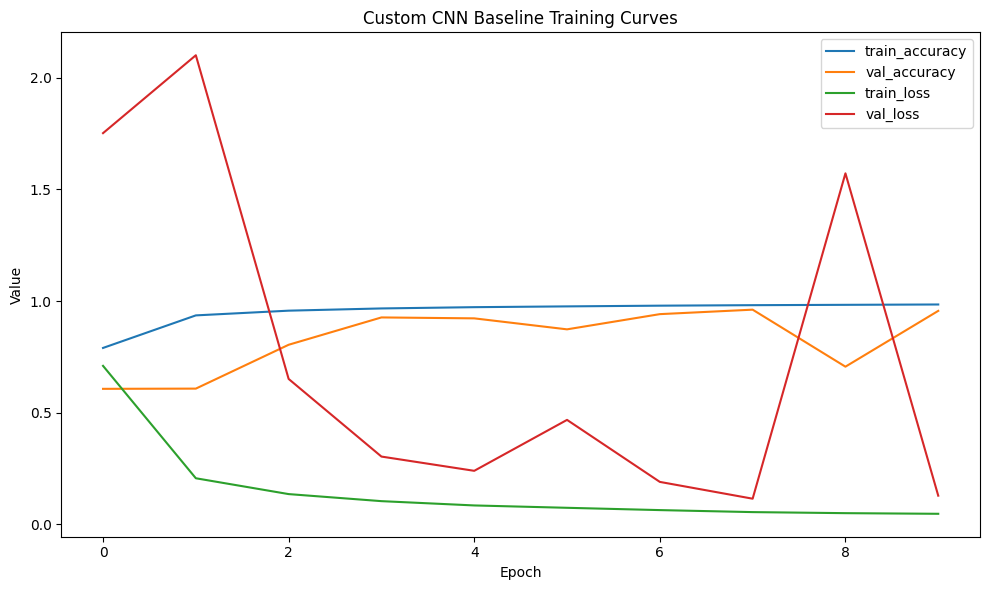

Saved: /kaggle/working/outputs/metrics/custom_cnn_training_curves.png


In [20]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(LOGS_DIR / "custom_cnn_history_from_notebook.csv", index=False)

plt.figure(figsize=(10, 6))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Custom CNN Baseline Training Curves")
plt.legend()
plt.tight_layout()

curve_path = METRICS_DIR / "custom_cnn_training_curves.png"
plt.savefig(curve_path, dpi=200)
plt.show()

print("Saved:", curve_path)

In [21]:
y_true = []
y_pred = []
y_prob = []

for images, labels in valid_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

y_true shape: (17572,)
y_pred shape: (17572,)
y_prob shape: (17572, 38)


In [22]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()

classification_report_path = METRICS_DIR / "custom_cnn_classification_report.csv"
report_df.to_csv(classification_report_path)

report_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,1.000000,0.914683,0.955440,504.0
Apple___Black_rot,0.942748,0.993964,0.967679,497.0
Apple___Cedar_apple_rust,0.984091,0.984091,0.984091,440.0
Apple___healthy,0.893048,0.998008,0.942615,502.0
Blueberry___healthy,0.988938,0.984581,0.986755,454.0


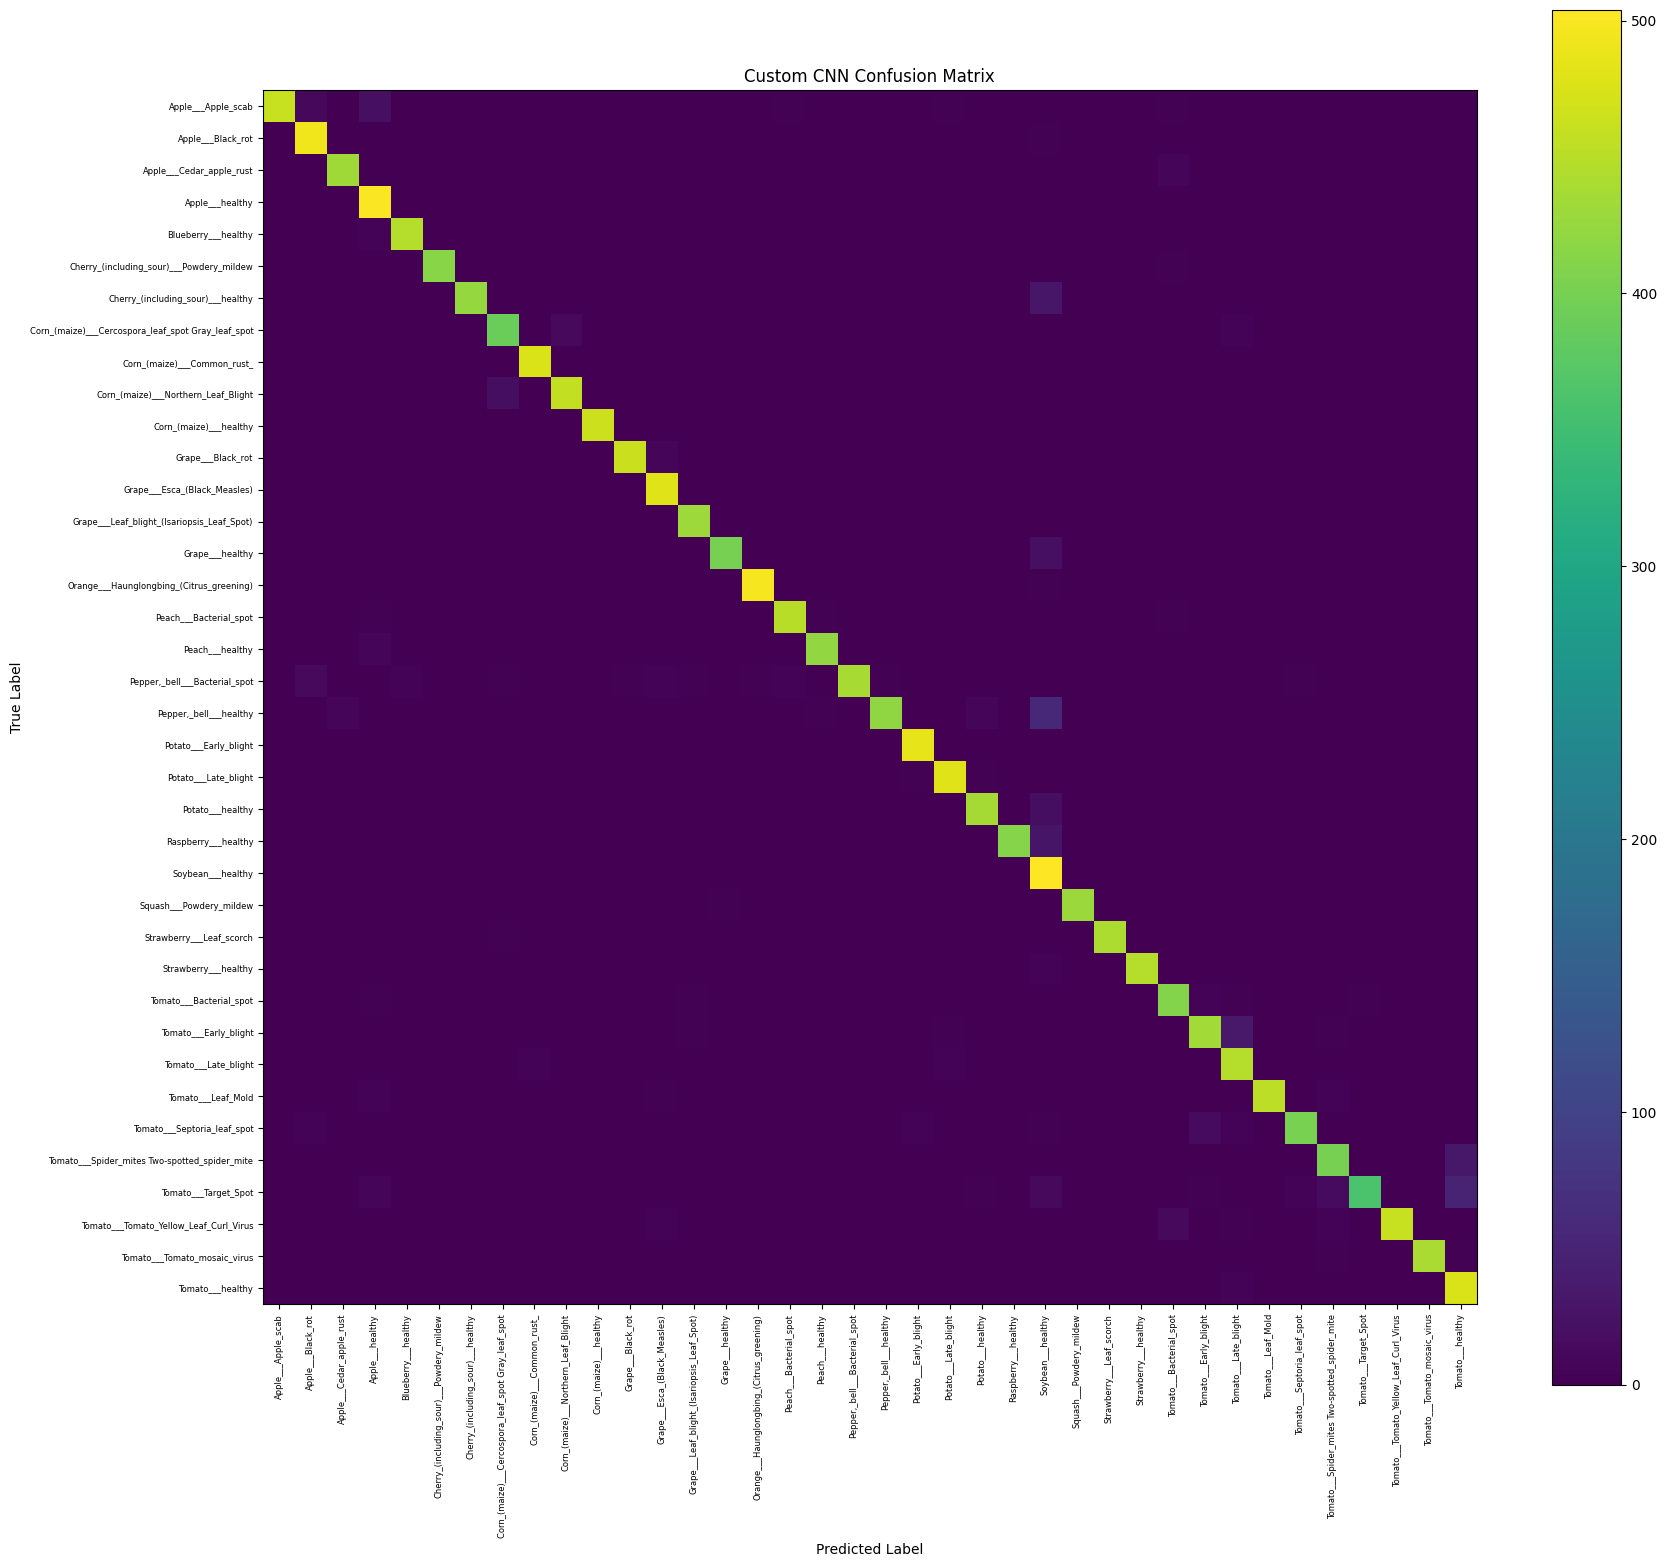

Saved: /kaggle/working/outputs/metrics/custom_cnn_confusion_matrix.png


In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title("Custom CNN Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=6)
plt.yticks(tick_marks, class_names, fontsize=6)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = METRICS_DIR / "custom_cnn_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=250)
plt.show()

print("Saved:", confusion_matrix_path)

In [24]:
wrong_indices = np.where(y_true != y_pred)[0]

error_summary = []

for idx in wrong_indices[:200]:
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = float(np.max(y_prob[idx]))

    error_summary.append({
        "true_class": true_label,
        "predicted_class": pred_label,
        "confidence": confidence,
    })

error_df = pd.DataFrame(error_summary)

error_path = ERROR_DIR / "custom_cnn_wrong_predictions_summary.csv"
error_df.to_csv(error_path, index=False)

error_df.head(20)

,true_class,predicted_class,confidence
0,Apple___Apple_scab,Tomato___Target_Spot,0.305928
1,Apple___Apple_scab,Peach___Bacterial_spot,0.811047
2,Apple___Apple_scab,Peach___Bacterial_spot,0.463753
3,Apple___Apple_scab,Apple___healthy,0.484331
4,Apple___Apple_scab,Potato___Early_blight,0.528925
5,Apple___Apple_scab,Apple___healthy,0.959163
6,Apple___Apple_scab,Apple___healthy,0.590697
7,Apple___Apple_scab,Apple___healthy,0.687810
8,Apple___Apple_scab,Apple___healthy,0.544281
9,Apple___Apple_scab,Apple___healthy,0.789637


In [26]:
model_metadata = {
    "project": "CropGuard AI",
    "model_name": "custom_cnn_baseline",
    "dataset": "Kaggle New Plant Diseases Dataset",
    "num_classes": num_classes,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "train_images": int(train_total),
    "valid_images": int(valid_total),
    "metrics": {
        "accuracy": float(results["accuracy"]),
        "loss": float(results["loss"]),
        "top_3_accuracy": float(results["top_3_accuracy"]),
    },
    "notes": [
        "This is the baseline CNN model.",
        "It is used for comparison against transfer learning models.",
        "This model should not be treated as final production-level performance.",
    ],
}

metadata_path = MODELS_DIR / "custom_cnn_model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved:", metadata_path)

Saved: /kaggle/working/models/custom_cnn_model_metadata.json


In [27]:
for path in WORKING_DIR.rglob("*"):
    if path.is_file():
        print(path)

/kaggle/working/models/custom_cnn_model_metadata.json
/kaggle/working/models/class_indices.json
/kaggle/working/models/custom_cnn_baseline.keras
/kaggle/working/models/class_weights.json
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/outputs/metrics/custom_cnn_confusion_matrix.png
/kaggle/working/outputs/metrics/custom_cnn_classification_report.csv
/kaggle/working/outputs/metrics/custom_cnn_sample_images.png
/kaggle/working/outputs/metrics/custom_cnn_class_distribution.png
/kaggle/working/outputs/metrics/custom_cnn_results.csv
/kaggle/working/outputs/metrics/custom_cnn_training_curves.png
/kaggle/working/outputs/metrics/dataset_distribution_custom_cnn.csv
/kaggle/working/outputs/error_analysis/custom_cnn_wrong_predictions_summary.csv
/kaggle/working/outputs/training_logs/custom_cnn_history_from_notebook.csv
/kaggle/working/outputs/training_logs/custom_cnn_history.csv


In [28]:
zip_path = WORKING_DIR / "cropguard_custom_cnn_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in [MODELS_DIR, OUTPUTS_DIR]:
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                zipf.write(file_path, file_path.relative_to(WORKING_DIR))

print("Created ZIP:", zip_path)

Created ZIP: /kaggle/working/cropguard_custom_cnn_outputs.zip


In [29]:
print("CUSTOM CNN TRAINING COMPLETE")
print("----------------------------")
print("Accuracy:", results["accuracy"])
print("Loss:", results["loss"])
print("Top-3 Accuracy:", results["top_3_accuracy"])
print("Model saved at:", model_path)
print("ZIP saved at:", zip_path)

CUSTOM CNN TRAINING COMPLETE
----------------------------
Accuracy: 0.9614158868789673
Loss: 0.11532531678676605
Top-3 Accuracy: 0.9976098537445068
Model saved at: /kaggle/working/models/custom_cnn_baseline.keras
ZIP saved at: /kaggle/working/cropguard_custom_cnn_outputs.zip
